In [1]:
import json
import os
import sys

import numpy as np
import pandas as pd
from river.decomposition import OnlineDMDwC
from river.preprocessing import Hankelizer
from river.utils import Rolling
from tqdm import tqdm

sys.path.append("../")

from functions.chdsubid import SubIDChangeDetector, get_default_rank
from functions.plot import plot_chd
from functions.preprocessing import hankel

Rolling.learn_one = Rolling.update  # type: ignore

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Read data
df = pd.read_csv("data/eco-pack/20230908_eco_pack_presov.csv", index_col=0)
df.index = pd.to_datetime(df.index)
df_u = pd.read_csv("data/eco-pack/20230908_model_input.csv", index_col=0).drop(
    columns=["Kokam_String:F_Module Fan Fault"]
)
df_u.index = pd.to_datetime(df_u.index)
n_u = df_u.shape[1]
aligned_df = df.merge(df_u, left_index=True, right_index=True)

y = aligned_df.pop("Kokam_String:F_Module Fan Fault")
U = aligned_df.iloc[:, -n_u:]
X = aligned_df.iloc[:, :-n_u]

In [4]:
window_size: int | None = 2 * 60 * 24
init_size = (
    window_size - 1
)  # Unsupervised usage reserves one iteration for contstructing y
# Base size
ref_size = 2 * 60 * 2
test_size = 4 * 60 * 2
# If window_size is not very large, then take half
h_max = 6
h_reco = window_size // 2
if h_reco < h_max:
    hn = h_reco
    hu = h_reco
    step = 1
else:
    hn = h_max
    hu = 1
    step = (window_size // 2) // h_max
# Optimal low-rank representation of signal with unknown noise variance
p = min(4, get_default_rank(hankel(X[:window_size], hn, step=step)))
print(f"Optimal rank for states is: {p}")
q = min(4, get_default_rank(hankel(U[:window_size], hu, step=step)))
print(f"Optimal rank for inputs is: {q}")
# Snapshots weighting
w = 1.0

Optimal rank for states is: 4
Optimal rank for inputs is: 4


In [5]:
# [donotremove]
# TODO: enable hankelization of us on the fly
U_ = pd.DataFrame(hankel(U, hn=hu))

# Initialize Hankelizer
hankelizer = Hankelizer(hn)

# Initialize Transformer
odmd = OnlineDMDwC(
    p=p,
    q=q,
    initialize=init_size,
    w=1.0,
    exponential_weighting=False,
    eig_rtol=1e-1,
)
if window_size:
    odmd = Rolling(odmd, window_size)

# Initialize Change-Point Detector
subid_dmd = SubIDChangeDetector(
    odmd,
    ref_size=ref_size,
    test_size=test_size,
    grace_period=init_size + test_size + 1,
)

# Build pipeline
pipeline_dmd = hankelizer | subid_dmd

# Prepare arrays for storing results
scores_dmd = np.zeros(X.shape[0], dtype=float)
scores_dmd_diff = np.zeros(X.shape[0], dtype=complex)
dist = np.zeros((X.shape[0], 2), dtype=complex)

# Run pipeline
for i, (x, u) in tqdm(
    enumerate(
        zip(
            X.to_dict(orient="records"),
            U_.to_dict(orient="records"),
        )
    ),
    total=len(X),
    mininterval=1.0,
    desc="Snapshots processed",
):
    scores_dmd[i] = pipeline_dmd.score_one(x)
    dist[i, :] = subid_dmd.distances
    scores_dmd_diff[i] = dist[i, 1] - dist[i, 0]

    try:
        pipeline_dmd.learn_one(x, **{"u": u})
    except np.linalg.LinAlgError, ValueError:
        pass  # SVD non-convergence or dimension mismatch on ill-conditioned data

Snapshots processed:   0%|          | 0/113363 [00:00<?, ?it/s]

Snapshots processed:   3%|▎         | 3442/113363 [00:01<00:32, 3413.92it/s]

Snapshots processed:   3%|▎         | 3442/113363 [00:20<00:32, 3413.92it/s]

Snapshots processed:   5%|▍         | 5409/113363 [00:20<08:06, 222.06it/s] 

Snapshots processed:   5%|▍         | 5547/113363 [00:21<08:18, 216.29it/s]

...

Snapshots processed: 100%|█████████▉| 113196/113363 [11:50:50<00:03, 49.92it/s]

Snapshots processed: 100%|█████████▉| 113248/113363 [11:50:51<00:02, 47.13it/s]

Snapshots processed: 100%|█████████▉| 113303/113363 [11:50:52<00:01, 49.11it/s]

Snapshots processed: 100%|█████████▉| 113360/113363 [11:50:53<00:00, 51.09it/s]

Snapshots processed: 100%|██████████| 113363/113363 [11:50:54<00:00,  2.66it/s]

/var/folders/r5/m56sdg656cj3mp06q32vtxrw0000gn/T/ipykernel_15483/3524220648.py:42: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(results_name + ".pdf")


/Users/mw/pyprojects/phd/researcher/odmd-subid-cpd/.venv/lib/python3.14/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


/Users/mw/pyprojects/phd/researcher/odmd-subid-cpd/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


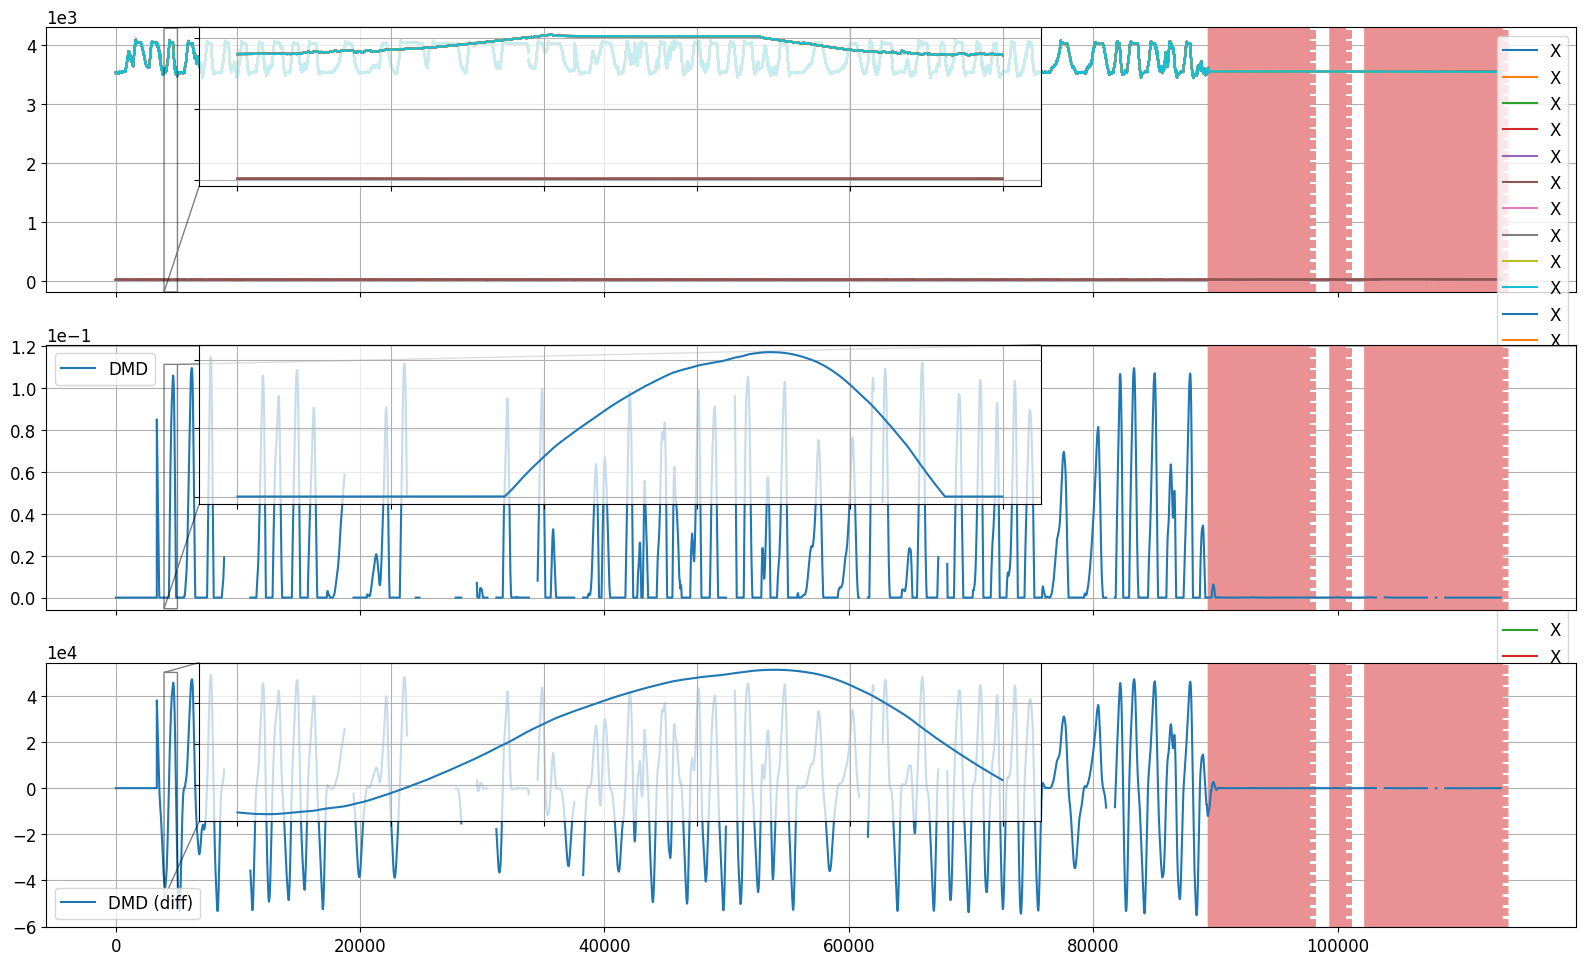

In [6]:
results_name = (
    f"results/.bess/bess-chd_p{p}-l{window_size}_b{ref_size}_t{test_size}"
    f"{'noroll' if window_size is None else f'roll_{window_size}'}-"
    f"dmd_w{w}-hx{hn}-imag"
)

if "scores_dmd" not in locals():
    if os.path.exists(results_name + ".json"):
        results = json.load(open(results_name + ".json"))
        scores_dmd = np.array(results["scores_dmd"])
        scores_dmd_diff = np.array(results["scores_dmd_diff"])
    else:
        raise ValueError("No results found. Please rerun the experiment.")
else:
    results = {
        "params": {
            "p": str(p),
            "window_size": str(window_size),
            "init_size": str(init_size),
            "ref_size": str(ref_size),
            "test_size": str(test_size),
            "hn": str(hn),
        },
        "scores_dmd": scores_dmd.real.tolist(),
        "scores_dmd_diff": scores_dmd_diff.real.tolist(),
    }
    os.makedirs(os.path.dirname(results_name), exist_ok=True)

    json.dump(results, open(results_name + ".json", "w"))

# Plot results
fig, axs = plot_chd(
    [X.values, scores_dmd.real, scores_dmd_diff.real],
    np.where(y == 1)[0],
    labels=["X", "DMD", "DMD (diff)", "SVD"],
    grace_period=test_size,
    ids_in_start=[4000],
    ids_in_end=[5000],
)
fig.set_size_inches(18, 10)  # Set the size of the figure

fig.savefig(results_name + ".pdf")